Categorical cols: ['parent_education_level', 'study_environment']
Numeric cols: ['previous_score', 'math_prev_score', 'science_prev_score', 'language_prev_score', 'daily_study_hours', 'attendance_percentage', 'homework_completion_rate', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'motivation_score', 'exam_anxiety_score']

Top 5 influential factors (Linear Regression on final_score):
            feature     coef
     previous_score 3.869748
    math_prev_score 3.422414
  daily_study_hours 3.028589
   motivation_score 2.231917
language_prev_score 2.202322
R2: 0.8771965293453549
MAE: 3.9778528657004273

Top 5 influential factors (Logistic Regression on pass_fail):
              feature     coef
      math_prev_score 1.308353
       previous_score 1.136647
     motivation_score 1.044480
attendance_percentage 0.945862
    daily_study_hours 0.840410

Logistic Regression Evaluation (test set):
Accuracy: 0.95
F1: 0.973404255319149
ROC-AUC: 0.978494623655914
Confusion Matri

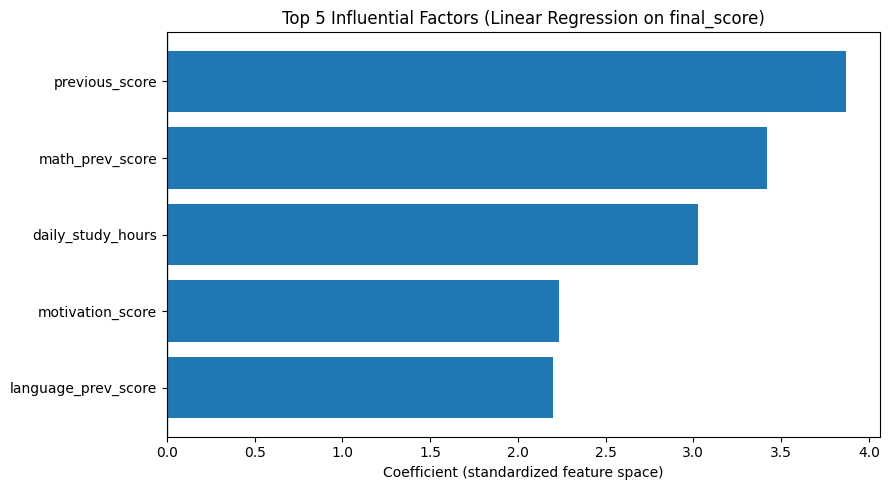

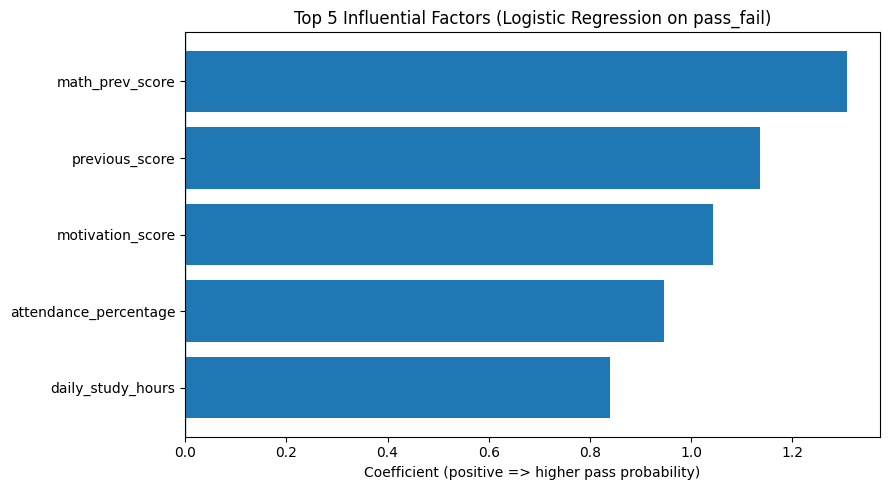

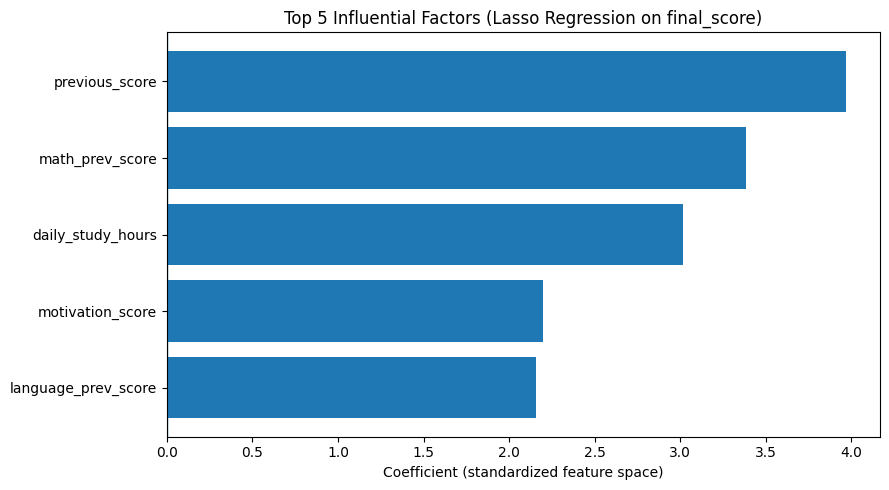


--- Correlation Analysis ---


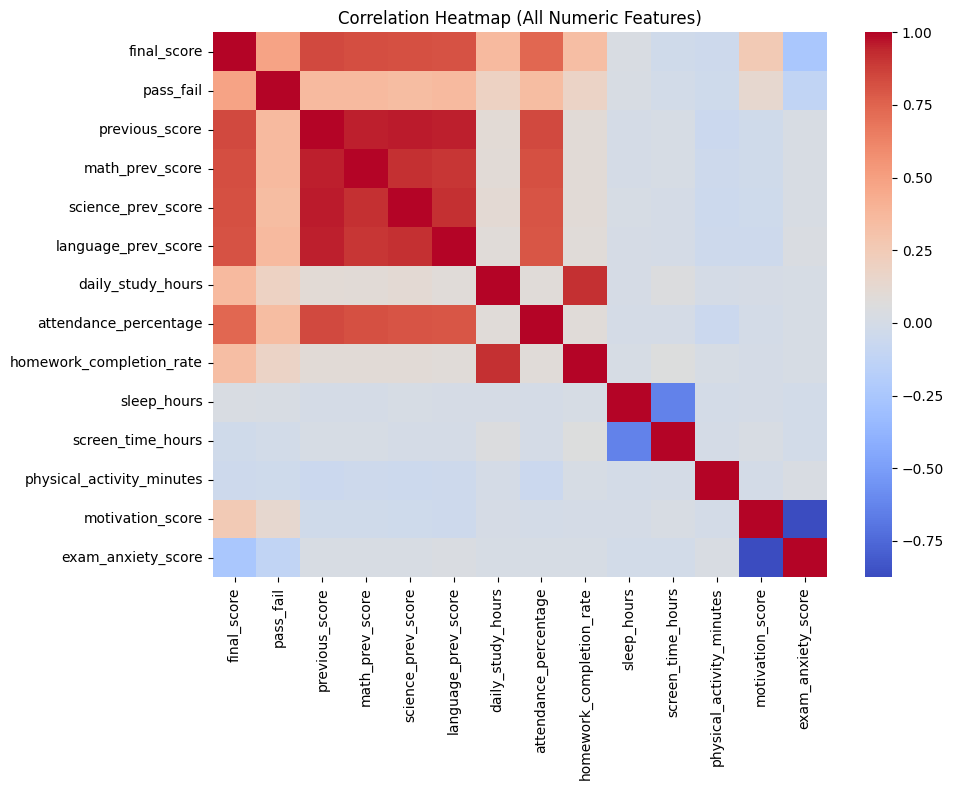

Heatmap displayed. High correlations among prior score variables may indicate multicollinearity.

--- Linear Regression WITHOUT Prior Scores ---
R² without prior scores: 0.7121
MAE without prior scores: 6.0913

--- Linear Regression with Actionable Factors Only ---
Actionable columns used: ['daily_study_hours', 'attendance_percentage', 'motivation_score', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'homework_completion_rate', 'exam_anxiety_score']
Actionable categorical cols: []
Actionable numeric cols: ['daily_study_hours', 'attendance_percentage', 'motivation_score', 'sleep_hours', 'screen_time_hours', 'physical_activity_minutes', 'homework_completion_rate', 'exam_anxiety_score']
R² (actionable only): 0.7158
MAE (actionable only): 5.9867


In [1]:
# Part 1: Setup + Load Data
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_object_dtype, is_string_dtype
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# CHANGE this directory to your dataset!!!
DATA_PATH = os.path.expanduser("~/Downloads/student_performance.csv")
df = pd.read_csv(DATA_PATH)

# Targets
y_reg = df["final_score"]     # continuous score for Linear + Lasso
y_clf = df["pass_fail"]       # 1 = pass, 0 = fail for Logistic
X = df.drop(columns=["student_id", "grade", "pass_fail", "final_score"])

# Train/test split
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Part 2: Preprocessing data (Numeric + Categorical)

cat_cols = [
    c for c in X.columns
    if (is_object_dtype(X[c]) or is_string_dtype(X[c]) or isinstance(X[c].dtype, pd.CategoricalDtype))
]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

def get_feature_names(preprocessor):
    num_names = list(num_cols)
    if len(cat_cols) > 0:
        cat_encoder = preprocessor.named_transformers_["cat"]
        cat_names = list(cat_encoder.get_feature_names_out(cat_cols))
    else:
        cat_names = []
    return num_names + cat_names

# Part 3: Linear Regression

lin_model = Pipeline([
    ("prep", preprocess),
    ("lr", LinearRegression()),
])

lin_model.fit(X_train, y_reg_train)

prep_fitted = lin_model.named_steps["prep"]
feature_names = get_feature_names(prep_fitted)
coef_lin = lin_model.named_steps["lr"].coef_

lin_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_lin,
    "abs_coef": np.abs(coef_lin),
}).sort_values("abs_coef", ascending=False)

top5_lin = lin_importance.head(5).copy()

print("\nTop 5 influential factors (Linear Regression on final_score):")
print(top5_lin[["feature", "coef"]].to_string(index=False))

# This is the evaluation part
y_pred = lin_model.predict(X_test)
print("R2:", r2_score(y_reg_test, y_pred))
print("MAE:", mean_absolute_error(y_reg_test, y_pred))


# Part 4: Logistic Regression

log_model = Pipeline([
    ("prep", preprocess),
    ("log", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

log_model.fit(X_train, y_clf_train)

prep_fitted = log_model.named_steps["prep"]
feature_names = get_feature_names(prep_fitted)
coef_log = log_model.named_steps["log"].coef_.ravel()

log_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_log,
    "abs_coef": np.abs(coef_log),
}).sort_values("abs_coef", ascending=False)

top5_log = log_importance.head(5).copy()

print("\nTop 5 influential factors (Logistic Regression on pass_fail):")
print(top5_log[["feature", "coef"]].to_string(index=False))

# This is the evaluation part
proba = log_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_clf_test, pred)
f1 = f1_score(y_clf_test, pred)
auc = roc_auc_score(y_clf_test, proba)
cm = confusion_matrix(y_clf_test, pred)

print("\nLogistic Regression Evaluation (test set):")
print("Accuracy:", acc)
print("F1:", f1)
print("ROC-AUC:", auc)
print("Confusion Matrix:\n", cm)


# Part 5: Lasso Regression

lasso_model = Pipeline([
    ("prep", preprocess),
    ("lasso", LassoCV(
        alphas=np.logspace(-4, 1, 80),
        cv=5,
        random_state=42,
        max_iter=50000
    ))
])

lasso_model.fit(X_train, y_reg_train)

prep_fitted = lasso_model.named_steps["prep"]
feature_names = get_feature_names(prep_fitted)
coef_lasso = lasso_model.named_steps["lasso"].coef_

lasso_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_lasso,
    "abs_coef": np.abs(coef_lasso),
}).sort_values("abs_coef", ascending=False)

top5_lasso = lasso_importance.head(5).copy()

print("\nTop 5 influential factors (Lasso Regression on final_score):")
print(top5_lasso[["feature", "coef"]].to_string(index=False))

# This is the evaluation part
y_pred = lasso_model.predict(X_test)
print("R2:", r2_score(y_reg_test, y_pred))
print("MAE:", mean_absolute_error(y_reg_test, y_pred))
print("Chosen alpha:", lasso_model.named_steps["lasso"].alpha_)
print("Non-zero features:", np.sum(lasso_model.named_steps["lasso"].coef_ != 0))

# Part 6: Visualization

def plot_top5(df_top5, title, xlabel):
    d = df_top5.copy().iloc[::-1]
    plt.figure(figsize=(9, 5))
    plt.barh(d["feature"], d["coef"])
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

# Linear Regression plot
plot_top5(
    top5_lin,
    "Top 5 Influential Factors (Linear Regression on final_score)",
    "Coefficient (standardized feature space)"
)

# Logistic Regression plot
plot_top5(
    top5_log,
    "Top 5 Influential Factors (Logistic Regression on pass_fail)",
    "Coefficient (positive => higher pass probability)"
)

# Lasso Regression plot
plot_top5(
    top5_lasso,
    "Top 5 Influential Factors (Lasso Regression on final_score)",
    "Coefficient (standardized feature space)"
)

# Part 7: Correlation Analysis (Multicollinearity Exploration)
# Purpose:
#   - Visualize correlations among numeric variables.
#   - Diagnose potential multicollinearity (e.g., prior score features might be highly correlated),
#     which explains why regularization methods like Lasso can be useful.


# Helper Function: build_preprocessor_for_X
def build_preprocessor_for_X(X_subset):
    # Identify categorical columns:
    # - object/string columns
    # - pandas categorical dtype
    cat_cols_subset = [
        c for c in X_subset.columns
        if is_object_dtype(X_subset[c])
        or is_string_dtype(X_subset[c])
        or isinstance(X_subset[c].dtype, pd.CategoricalDtype)
    ]

    # Identify numeric columns as "the rest"
    num_cols_subset = [c for c in X_subset.columns if c not in cat_cols_subset]

    # Define transformations:
    # - OneHotEncoder for categorical data (handle_unknown='ignore' prevents errors on unseen categories)
    # - StandardScaler for numeric data (helps linear models by putting variables on comparable scales)
    cat_transformer = OneHotEncoder(handle_unknown="ignore")
    num_transformer = StandardScaler()

    # Build ColumnTransformer: applies different preprocessing to different column groups
    preproc_subset = ColumnTransformer(
        transformers=[
            ("cat", cat_transformer, cat_cols_subset),
            ("num", num_transformer, num_cols_subset),
        ],
        remainder="drop"  # drop any columns not explicitly listed above
    )

    # Return:
    # - the preprocessor
    # - the categorical column names
    # - the numeric column names
    return preproc_subset, cat_cols_subset, num_cols_subset

# Correlation heatmap plotting
print("\n--- Correlation Analysis ---")

# Plot correlation matrix for numeric columns (df.corr() only uses numeric features)
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()

print("Heatmap displayed. High correlations among prior score variables may indicate multicollinearity.")

# Part 8: Model Without Prior Academic Performance
print("\n--- Linear Regression WITHOUT Prior Scores ---")

# Define the set of prior-performance-related columns
prior_cols = [
    "previous_score",
    "math_prev_score",
    "science_prev_score",
    "language_prev_score"
]

# Drop prior score columns if they exist in X
X_no_prior = X.drop(columns=[c for c in prior_cols if c in X.columns])

# Train/test split for the no-prior dataset
Xnp_train, Xnp_test, ynp_train, ynp_test = train_test_split(
    X_no_prior, y_reg, test_size=0.2, random_state=42
)

# Build a NEW preprocessor specifically for X_no_prior
# (avoids referencing removed columns)
preproc_np, cat_np, num_np = build_preprocessor_for_X(X_no_prior)

# Linear Regression pipeline:
# preprocess -> LinearRegression
model_no_prior = Pipeline(steps=[
    ("preprocess", preproc_np),
    ("regressor", LinearRegression())
])

# Fit the model
model_no_prior.fit(Xnp_train, ynp_train)

# Predict on test set
y_pred_np = model_no_prior.predict(Xnp_test)

# Evaluate model performance
r2_np = r2_score(ynp_test, y_pred_np)
mae_np = mean_absolute_error(ynp_test, y_pred_np)

print(f"R² without prior scores: {r2_np:.4f}")
print(f"MAE without prior scores: {mae_np:.4f}")

# Part 9: Actionable Factors Only Model
print("\n--- Linear Regression with Actionable Factors Only ---")

# Define a list of actionable (behavioral / lifestyle) features
actionable_cols = [
    "daily_study_hours",
    "attendance_percentage",
    "motivation_score",
    "sleep_hours",
    "screen_time_hours",
    "physical_activity_minutes",
    "homework_completion_rate",
    "exam_anxiety_score",
]

# Keep only actionable columns that exist in X
X_action = X[[c for c in actionable_cols if c in X.columns]].copy()
print("Actionable columns used:", list(X_action.columns))

# Train/test split for actionable-only dataset
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_action, y_reg, test_size=0.2, random_state=42
)

# Build a NEW preprocessor for X_action
# (this subset likely has no categorical columns, but this keeps it robust)
preproc_a, cat_a, num_a = build_preprocessor_for_X(X_action)
print("Actionable categorical cols:", cat_a)
print("Actionable numeric cols:", num_a)

# Linear Regression pipeline for actionable-only features
model_action = Pipeline(steps=[
    ("preprocess", preproc_a),
    ("regressor", LinearRegression())
])

# Fit and predict
model_action.fit(Xa_train, ya_train)
y_pred_a = model_action.predict(Xa_test)

# Evaluate actionable-only model performance
r2_a = r2_score(ya_test, y_pred_a)
mae_a = mean_absolute_error(ya_test, y_pred_a)

print(f"R² (actionable only): {r2_a:.4f}")
print(f"MAE (actionable only): {mae_a:.4f}")